In [71]:
! pip install numpy
! pip install matplotlib
! pip install pandas

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [210]:
# read science data line by line, parse json, and store in a list
filename = 'batch_20240411_1440_MITMBA.scienceData.jsonl'
data = []

with open(filename) as f:
    for line in f:
        parsed = json.loads(line)
        if parsed['sampleId'] != 'missing':
            data.append(parsed)

sorted_data = sorted(data, key=lambda x: x['treatment']['name']+x['gameId'])

new_data = []
game_lookups = {}
game_index = 0
for i, row in enumerate(sorted_data):
    row["player"] = i
    if row["gameId"] not in game_lookups:
        game_lookups[row["gameId"]] = game_index
        row["game"] = game_index
        game_index += 1
    else:
        row["game"] = game_lookups[row["gameId"]]

    new_data.append(row)

data = new_data
index = pd.MultiIndex.from_tuples([(row['treatment']["name"], row['game'], row['player']) for row in data], names=['treatment', 'game', 'player'])
len(data)

14

In [111]:
print(list(data[0].keys()))

['containerTag', 'deliberationId', 'sampleId', 'browserInfo', 'connectionInfo', 'batchId', 'config', 'timeBatchInitialized', 'timeArrived', 'timeEnteredCountdown', 'timeIntroDone', 'timeStarted', 'timeComplete', 'consent', 'introSequence', 'gameId', 'treatment', 'position', 'recordingsFolder', 'recordingRoomName', 'recordingsPath', 'recordingIds', 'surveys', 'prompts', 'qualtrics', 'stageSubmissions', 'QCSurvey', 'exitStatus', 'connectionHistory', 'speakerEvents', 'reports', 'checkIns', 'textChats', 'cumulativeSpeakingTime', 'exportErrors', 'player', 'game']


In [211]:
treatments = pd.DataFrame([row["treatment"]["name"] for row in data], columns=["treatment"], index=index)
treatments

treatment
treatment game player           
nonschema 0    0       nonschema
               1       nonschema
          1    2       nonschema
               3       nonschema
          2    4       nonschema
               5       nonschema
          3    6       nonschema
               7       nonschema
schema    4    8          schema
               9          schema
          5    10         schema
               11         schema
          6    12         schema
               13         schema

In [212]:
connection_info = pd.DataFrame([row['connectionInfo'] for row in data], index=index)
connection_info

country          timezone  isKnownVpn timezoneOffset  \
treatment game player                                                        
nonschema 0    0           US   America/Chicago       False         -05:00   
               1           US   America/Chicago       False         -05:00   
          1    2           US  America/New_York       False         -04:00   
               3           US  America/New_York       False         -04:00   
          2    4           US  America/New_York       False         -04:00   
               5           US  America/New_York       False         -04:00   
          3    6           US  America/New_York       False         -04:00   
               7           US  America/New_York       False         -04:00   
schema    4    8           US  America/New_York       False         -04:00   
               9           US  America/New_York       False         -04:00   
          5    10          US  America/New_York       False         -04:00   
               11          US  America/New_York       False         -04:00   
          6    12          US  America/New_York       False         -04:00   
               13          US  America/New_York       False         -04:00   

                       isLikelyVpn  
treatment game player               
nonschema 0    0              True  
               1              True  
          1    2             False  
               3             False  
          2    4             False  
               5             False  
          3    6             False  
               7             False  
schema    4    8             False  
               9             False  
          5    10            False  
               11            False  
          6    12            False  
               13            False

In [213]:
connection_info['country'].value_counts()

country
US    14
Name: count, dtype: int64

In [214]:
browser_info = pd.DataFrame([row['browserInfo'] for row in data], index=index)
browser_info

width  height  \
treatment game player                  
nonschema 0    0        1470     854   
               1        1440     875   
          1    2        1470     860   
               3        1470     824   
          2    4        1493     885   
               5        1280     672   
          3    6        1280     672   
               7        1470     854   
schema    4    8        1512     950   
               9        1920    1032   
          5    10       1440     821   
               11       2560    1355   
          6    12       1280     672   
               13       1470     919   

                                                               userAgent  \
treatment game player                                                      
nonschema 0    0       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               1       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          1    2       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               3       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          2    4       Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
               5       Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
          3    6       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
               7       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
schema    4    8       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               9       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          5    10      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               11      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          6    12      Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
               13      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   

                      language          timezone  
treatment game player                             
nonschema 0    0         en-US  America/New_York  
               1         en-US  America/New_York  
          1    2         en-US  America/New_York  
               3         en-US  America/New_York  
          2    4         en-US  America/New_York  
               5         en-US  America/New_York  
          3    6         en-US  America/New_York  
               7         en-US  America/New_York  
schema    4    8         en-US  America/New_York  
               9         en-US  America/New_York  
          5    10        en-US  America/New_York  
               11        en-US  America/New_York  
          6    12        ko-KR  America/New_York  
               13        en-US  America/New_York

In [215]:
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in data], index=index)
QC

technicalProblems joiningProblems  videoQuality  \
treatment game player                                                   
nonschema 0    0                     no              no           5.0   
               1                     no              no           5.0   
          1    2                    NaN             NaN           NaN   
               3                     no              no           3.0   
          2    4                     no              no           5.0   
               5                     no              no           4.0   
          3    6                     no              no           4.0   
               7                     no              no           4.0   
schema    4    8                     no              no           5.0   
               9                     no              no           4.0   
          5    10                    no              no           4.0   
               11                    no              no           5.0   
          6    12                   NaN             NaN           NaN   
               13                    no              no           5.0   

                       clearInstructions adequateTime adequateCompensation  \
treatment game player                                                        
nonschema 0    0                     5.0     adequate                  N/A   
               1                     4.0     too_much                  N/A   
          1    2                     NaN          NaN                  NaN   
               3                     2.0     too_much                  N/A   
          2    4                     4.0     adequate                  N/A   
               5                     4.0     adequate                  N/A   
          3    6                     5.0     adequate            underpaid   
               7                     5.0     too_much                  N/A   
schema    4    8                     5.0     too_much            underpaid   
               9                     4.0     adequate                  N/A   
          5    10                    4.0     adequate                  N/A   
               11                    4.0     adequate                  N/A   
          6    12                    NaN          NaN                  NaN   
               13                    5.0     adequate                  N/A   

                      participateAgain  \
treatment game player                    
nonschema 0    0                 maybe   
               1                 maybe   
          1    2                   NaN   
               3                 maybe   
          2    4                 maybe   
               5                 maybe   
          3    6                 maybe   
               7                 maybe   
schema    4    8                 maybe   
               9                 maybe   
          5    10                maybe   
               11                maybe   
          6    12                  NaN   
               13                  yes   

                                                           textExpansion  
treatment game player                                                     
nonschema 0    0                                                     NaN  
               1       When others joined, I did not have a chance to...  
          1    2                                                     NaN  
               3                                                     NaN  
          2    4                                                     NaN  
               5                                                     NaN  
          3    6                                                     NaN  
               7                                                     NaN  
schema    4    8                                                     NaN  
               9                                                     NaN  
          5    10              

In [216]:
for i, row in QC.iterrows():
    print(row["textExpansion"])

nan
When others joined, I did not have a chance to review the initial instructions. 
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [217]:
demographics = pd.DataFrame([(row["surveys"]["survey_Demographics_unknown_postIntro"]["responses"] if "survey_Demographics_unknown_postIntro" in row["surveys"] else {}) for row in data], index=index)
demographics

birth_year language_primary  english_written  \
treatment game player                                                
nonschema 0    0            1997          Chinese                5   
               1            1980         Japanese                4   
          1    2            1995          English                5   
               3            1997             Thai                4   
          2    4            1989          Spanish                4   
               5            1983          English                5   
          3    6            1995          English                5   
               7            1996          English                5   
schema    4    8            1994          English                5   
               9            1991          English                5   
          5    10           1999          English                5   
               11           1984          English                5   
          6    12           1992          English                5   
               13           1995          English                5   

                       english_spoken employment_status country_reside  \
treatment game player                                                    
nonschema 0    0                    5         A student  United States   
               1                    4         A student  United States   
          1    2                    5         A student  United States   
               3                    4         A student  United States   
          2    4                    4         A student  United States   
               5                    5           Retired  United States   
          3    6                    5         A student  United States   
               7                    5         A student  United States   
schema    4    8                    5         A student  United States   
               9                    5         A student  United States   
          5    10                   5         A student  United States   
               11                   5         A student  United States   
          6    12                   5         A student  United States   
               13                   5         A student  United States   

                       gender education_US latin_US  \
treatment game player                                 
nonschema 0    0       female            6       No   
               1         male            6       No   
          1    2       female            7       No   
               3       female            6       No   
          2    4       female            6      Yes   
               5         male            7       No   
          3    6       female            6       No   
               7       female            6      Yes   
schema    4    8         male            7      NaN   
               9       female            6       No   
          5    10      female            6      Yes   
               11        male            7       No   
          6    12        male            6      NaN   
               13      female            6       No   

                                           race_US  \
treatment game player                                
nonschema 0    0                           [Asian]   
               1                           [Asian]   
          1    2       [Black or African-American]   
               3                           [Asian]   
          2    4                           [Other]   
               5       [Black or African-American]   
          3    6                           [Asian]   
               7                           [White]   
schema    4    8                           [White]   
               9                    [Asian, White]   
          5    10                          [White]   
               11                          [Asian]   
          6    12                          [Asian]   
               13        

In [218]:
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in data], index=index)
submit_times

submitButton_labeling_1  submitButton_recall_1_1  \
treatment game player                                                     
nonschema 0    0                       307.863                    6.196   
               1                       308.037                    4.814   
          1    2                       333.460                    4.679   
               3                       333.754                    7.783   
          2    4                       176.277                    6.810   
               5                       175.767                    5.241   
          3    6                       246.319                    8.106   
               7                       247.060                   13.768   
schema    4    8                       250.370                    5.955   
               9                       250.801                   18.390   
          5    10                      198.421                   10.058   
               11                      198.716                    7.163   
          6    12                      150.224                    8.658   
               13                      149.457                    7.914   

                       submitButton_recall_1_2  submitButton_recall_1_4  \
treatment game player                                                     
nonschema 0    0                         3.795                    5.666   
               1                         3.026                    3.884   
          1    2                         3.442                    2.876   
               3                         3.696                    1.928   
          2    4                         5.630                    4.828   
               5                         4.149                    4.361   
          3    6                         3.254                    6.328   
               7                         5.905                    3.997   
schema    4    8                        10.253                    9.595   
               9                        10.695                    8.063   
          5    10                        8.227                    4.565   
               11                       11.343                    6.679   
          6    12                        7.074                    5.988   
               13                        5.350                    5.298   

                       submitButton_labeling_2  submitButton_recall_2_1  \
treatment game player                                                     
nonschema 0    0                       304.357                   11.159   
               1                       304.578                    7.072   
          1    2                       242.612                    4.846   
               3                       243.815                    2.109   
          2    4                       272.629                   17.230   
               5                       273.285                   22.663   
          3    6                       201.808                    2.745   
               7                       200.463                    4.442   
schema    4    8                       131.271                    8.086   
               9                       131.718                    6.505   
          5    10                       84.405                    6.716   
               11                       84.508                    6.893   
          6    12                      170.046                    4.692   
               13                      170.253                    4.970   

                       submitButton_recall_2_2  submitButton_recall_2_3  \
treatment game player                                                     
nonschema 0    0                         9.638                    7.755   
               1                         6.811                    6.952   
          1    2                         3.613                    5.153   
               3                         1.87

Text(0.5, 1.0, 'Time to coordinate labels')

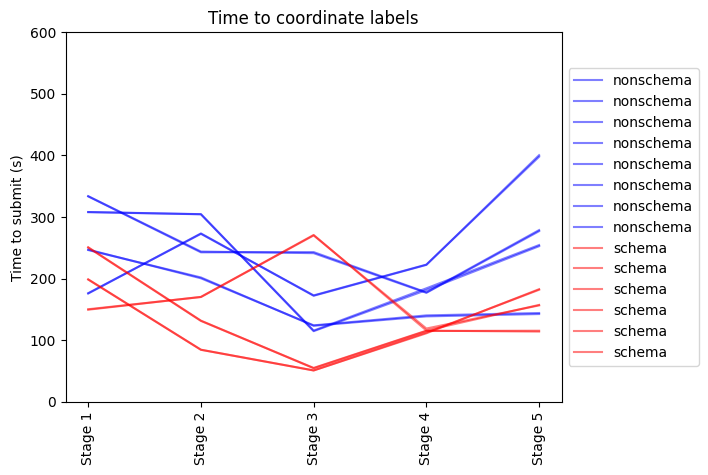

In [219]:
labeling_stages = [label for label in submit_times.columns if 'labeling' in label]

for i, row in submit_times.iterrows():
    plt.plot(row[labeling_stages], c=('blue' if i[0] == 'nonschema' else 'red'), alpha=0.5, label=f"{i[0]}")

plt.xticks(rotation=90)
plt.ylim(0, 600)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xticks(range(len(labeling_stages)),[re.sub(r'submitButton_labeling_', 'Stage ', label) for label in labeling_stages])
plt.ylabel('Time to submit (s)')
plt.title("Time to coordinate labels")

Text(0.5, 1.0, 'Time to recall labels')

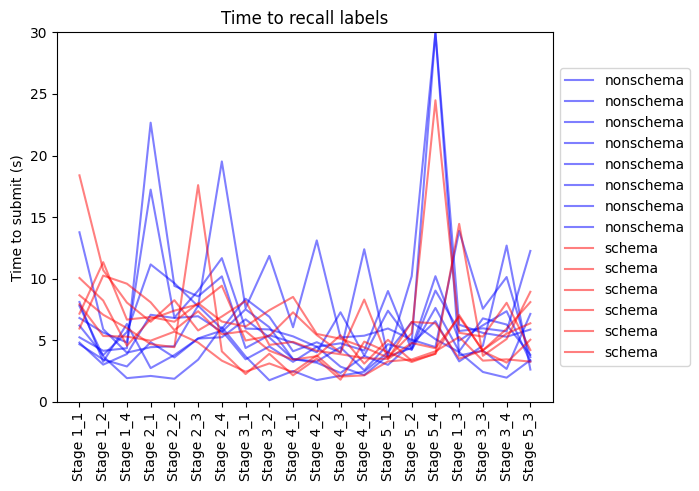

In [220]:
recall_stages = [label for label in submit_times.columns if 'recall' in label]

for i, row in submit_times.iterrows():
    plt.plot(row[recall_stages].fillna(30), c=('blue' if i[0] == 'nonschema' else 'red'), alpha=0.5, label=f"{i[0]}")

plt.xticks(rotation=90)
plt.ylim(0, 30)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xticks(range(len(recall_stages)),[re.sub(r'submitButton_recall_', 'Stage ', label) for label in recall_stages])
plt.ylabel('Time to submit (s)')
plt.title("Time to recall labels")

In [221]:
print(data[0]['prompts']['prompt_labeling_2']['value'])

Image 1: red right grey
Image 2: red right white
Image 3: red left white
Image 4: yellow left white
Image 5: yellow right white
Image 6: yellow left grey
Image 7: yellow right grey
Image 8: red left grey



In [222]:
data[0]['treatment']["name"]

'nonschema'

In [223]:
def extract_word(cell):
    return str(cell).split(":")[1].strip().lower()

    # pattern = r"Image \d+:\s*(\w+\s)\s*"
    # match = re.search(pattern, str(cell), re.IGNORECASE)
    # return match.group(1) if match else cell

labels_collector = []
for row in data:
    row_labels = {}
    for key, d in row['prompts'].items():
        if 'labeling' in key:
            round = key.split('_')[2]
            round_labels = [extract_word(line) for line in d['value'].split("\n") if len(line.strip()) > 0]
            for i, label in enumerate(round_labels):
                row_labels[(round, i+1)] = label
    labels_collector.append(row_labels)
labels = pd.DataFrame(labels_collector, index=index).T
labels.index = pd.MultiIndex.from_tuples(labels.index, names=['round', 'image'])
labels = labels.T.groupby(level=["treatment", "game"]).first().T
labels

treatment             nonschema                                   \
game                          0         1 2                    3   
round image                                                        
1     1                     dog   eyeball                   crab   
      2                       t   octopus                      t   
      3                    tube    spiral                  skirt   
      4                    crab      wide          black squares   
      5                  shorty    wall-e                 smiley   
      6                   board    square                   wall   
      7                     eye       uno                one eye   
      8                big foot     robot              big shoes   
2     1          red right grey   bigfeet              red beret   
      2         red right white      wide                    gap   
      3          red left white       hug                rooster   
      4       yellow left white    square              big mouth   
      5      yellow right white     round                   eggs   
      6        yellow left grey     short                  short   
      7       yellow right grey     robot           yellow beret   
      8           red left grey  widefeet            spread feet   
3     1       yellow left white     brown      yellow blue white   
      2           red left grey     santa          red blue navy   
      3          red left white       pig         red blue white   
      4       yellow right grey      tilt     yellow purple navy   
      5        yellow left grey      neck       yellow blue navy   
      6          red right grey     black         red white navy   
      7      yellow right white   snowman    yellow purple white   
      8         red right white      pink       red purple white   
4     1                    lady   eyelash                 purple   
      2                    crab      crab                   crab   
      3                 octopus  eyeballs                octopus   
      4                  police      legs               skeleton   
      5                   train     train                    owl   
      6                 balloon    purple                 tongue   
      7                  yellow    yellow                   fish   
      8                   round     round                  sleep   
5     1                   teach  straight                 priest   
      2                    slip      kick                   kick   
      3                    hard     kneel                  wings   
      4                   kneel      pray                  kneel   
      5                   dance   stretch                  dance   
      6                    bend       sit                    sit   
      7                     fly      fall                   arms   
      8                   glide   backleg                  skate   

treatment           schema                                           
game                     4                  5                     6  
round image                                                          
1     1               lrsw             red in      left-long-ballet  
      2               lytb  yellow down right   left-short-straight  
      3               lrsb     red right down     left-short-ballet  
      4               lytw        yellow down    left-long-straight  
      5               rytw        yellow left   right-long-straight  
      6               rrsb      red down left    right-short-ballet  
      7               rytb   yellow left down  right-short-straight  
      8               rrsw          red right     right-long-ballet  
2     1               rrsb      red down left               no-body  
      2               rrsw          red right               bathtub  
      3               lrsw             red in                skinny  
      4               lytw        yellow down                    tv  
      5               ryt

In [227]:
recall = pd.DataFrame([{key: d['value'] for key, d in row['prompts'].items() if 'recall' in key} for row in data], index=index).applymap(lambda x: str(x).lower().strip()).T
recall_index = pd.MultiIndex.from_tuples(pd.Series(recall.index).apply(lambda x: x.split("_")[2:]), names=["round", "stage"])
recall.index = recall_index
recall.sort_index(inplace=True)
recall


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_52783/2774299999.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  recall = pd.DataFrame([{key: d['value'] for key, d in row['prompts'].items() if 'recall' in key} for row in data], index=index).applymap(lambda x: str(x).lower().strip()).T


treatment            nonschema                                         \
game                         0                            1             
player                      0                  1         2         3    
round stage                                                             
1     1                      t                  t   octopus   octopus   
      2                  board              board    square    square   
      3               big foot           big foot     robot     robot   
      4                    eye                eye       uno       uno   
2     1        red right white    red right white      wide      wide   
      2       yellow left grey   yellow left grey     short     short   
      3      yellow right grey  yellow right grey     robot     robot   
      4          red left grey      red left grey  widefeet  widefeet   
3     1      yellow left white  yellow left white     brown     brown   
      2         red right grey     red right grey     black     black   
      3        red right white    red right white      pink      pink   
      4      yellow right grey  yellow right grey      tilt      tilt   
4     1                   crab               crab      crab      crab   
      2                balloon            balloon    purple    purple   
      3                 yellow             yellow    yellow    yellow   
      4                  train              train     train     train   
5     1                  glide              glide   backleg   backleg   
      2                  dance              dance   stretch   stretch   
      3                   hard               hard     kneel     kneel   
      4                  dance              dance   stretch   stretch   

treatment                                                        \
game                      2                                   3   
player                   4               5                   6    
round stage                                                       
1     1                   t               t                   t   
      2      sheet of paper  sheet of paper                wall   
      3         caterpillar     caterpillar           big shoes   
      4              webcam          webcam             one eye   
2     1           red train       train man                 gap   
      2            lego man        lego man               short   
      3          yellow box      yellow box        yellow beret   
      4             red box         red box         spread feet   
3     1                yoda            yoda   yellow blue white   
      2        black camera    black camera      red white navy   
      3            pink man        pink man    red purple white   
      4            ring man        ring man  yellow purple navy   
4     1          red palace      red palace                crab   
      2               clown           clown              tongue   
      3        yellow sheet    yellow sheet                fish   
      4               train           train                 owl   
5     1          stretching      stretching               skate   
      2              karate          karate               dance   
      3           communion             nun                arms   
      4              karate          karate               dance   

treatment                         schema                              \
game                                   4                           5   
player                       7        8        9                  10   
round stage                                                            
1     1                       t     lytw     lytw        yellow down   
      2                    wall     rrsb     rrsb      red down left   
      3               big shoes     rrsw     rrsw          red right   
      4                 one eye     rytb     rytb   yellow left down   
2     1                     gap     rrsw     rrsw          red

In [228]:
# group by game and check if the players within the game have matching values
matches = recall.T.groupby(level=['treatment', 'game']).apply(lambda x: x.nunique()==1).T
matches

treatment   nonschema                     schema             
game                0     1      2      3      4      5     6
round stage                                                  
1     1          True  True   True   True   True   True  True
      2          True  True   True   True   True   True  True
      3          True  True   True   True   True   True  True
      4          True  True   True   True   True   True  True
2     1          True  True  False   True   True   True  True
      2          True  True   True   True   True   True  True
      3          True  True   True   True   True   True  True
      4          True  True   True  False   True   True  True
3     1          True  True   True   True   True   True  True
      2          True  True   True   True   True  False  True
      3          True  True   True   True   True   True  True
      4          True  True   True   True   True   True  True
4     1          True  True   True   True   True   True  True
      2          True  True   True  False   True   True  True
      3          True  True   True   True   True   True  True
      4          True  True   True   True   True   True  True
5     1          True  True   True   True   True   True  True
      2          True  True   True   True   True   True  True
      3          True  True  False  False   True  False  True
      4          True  True   True   True  False   True  True

In [229]:
match_counts = matches.groupby(level="round").sum()
match_counts

treatment nonschema          schema      
game              0  1  2  3      4  5  6
round                                    
1                 4  4  4  4      4  4  4
2                 4  4  3  3      4  4  4
3                 4  4  4  4      4  3  4
4                 4  4  4  3      4  4  4
5                 4  4  3  3      3  3  4

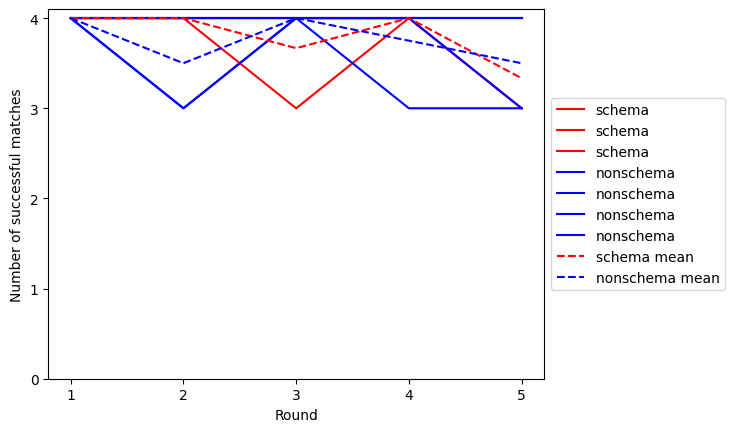

In [236]:
plt.plot(match_counts["schema"], c='red', label='schema')
plt.plot(match_counts["nonschema"], c='blue', label='nonschema')
plt.plot(match_counts["schema"].mean(axis=1), '--', c='red', label='schema mean')
plt.plot(match_counts["nonschema"].mean(axis=1), '--', c='blue', label='nonschema mean')
plt.ylim(0, 4.1)
plt.xlabel("Round")
plt.ylabel("Number of successful matches")
plt.yticks(range(5))
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
